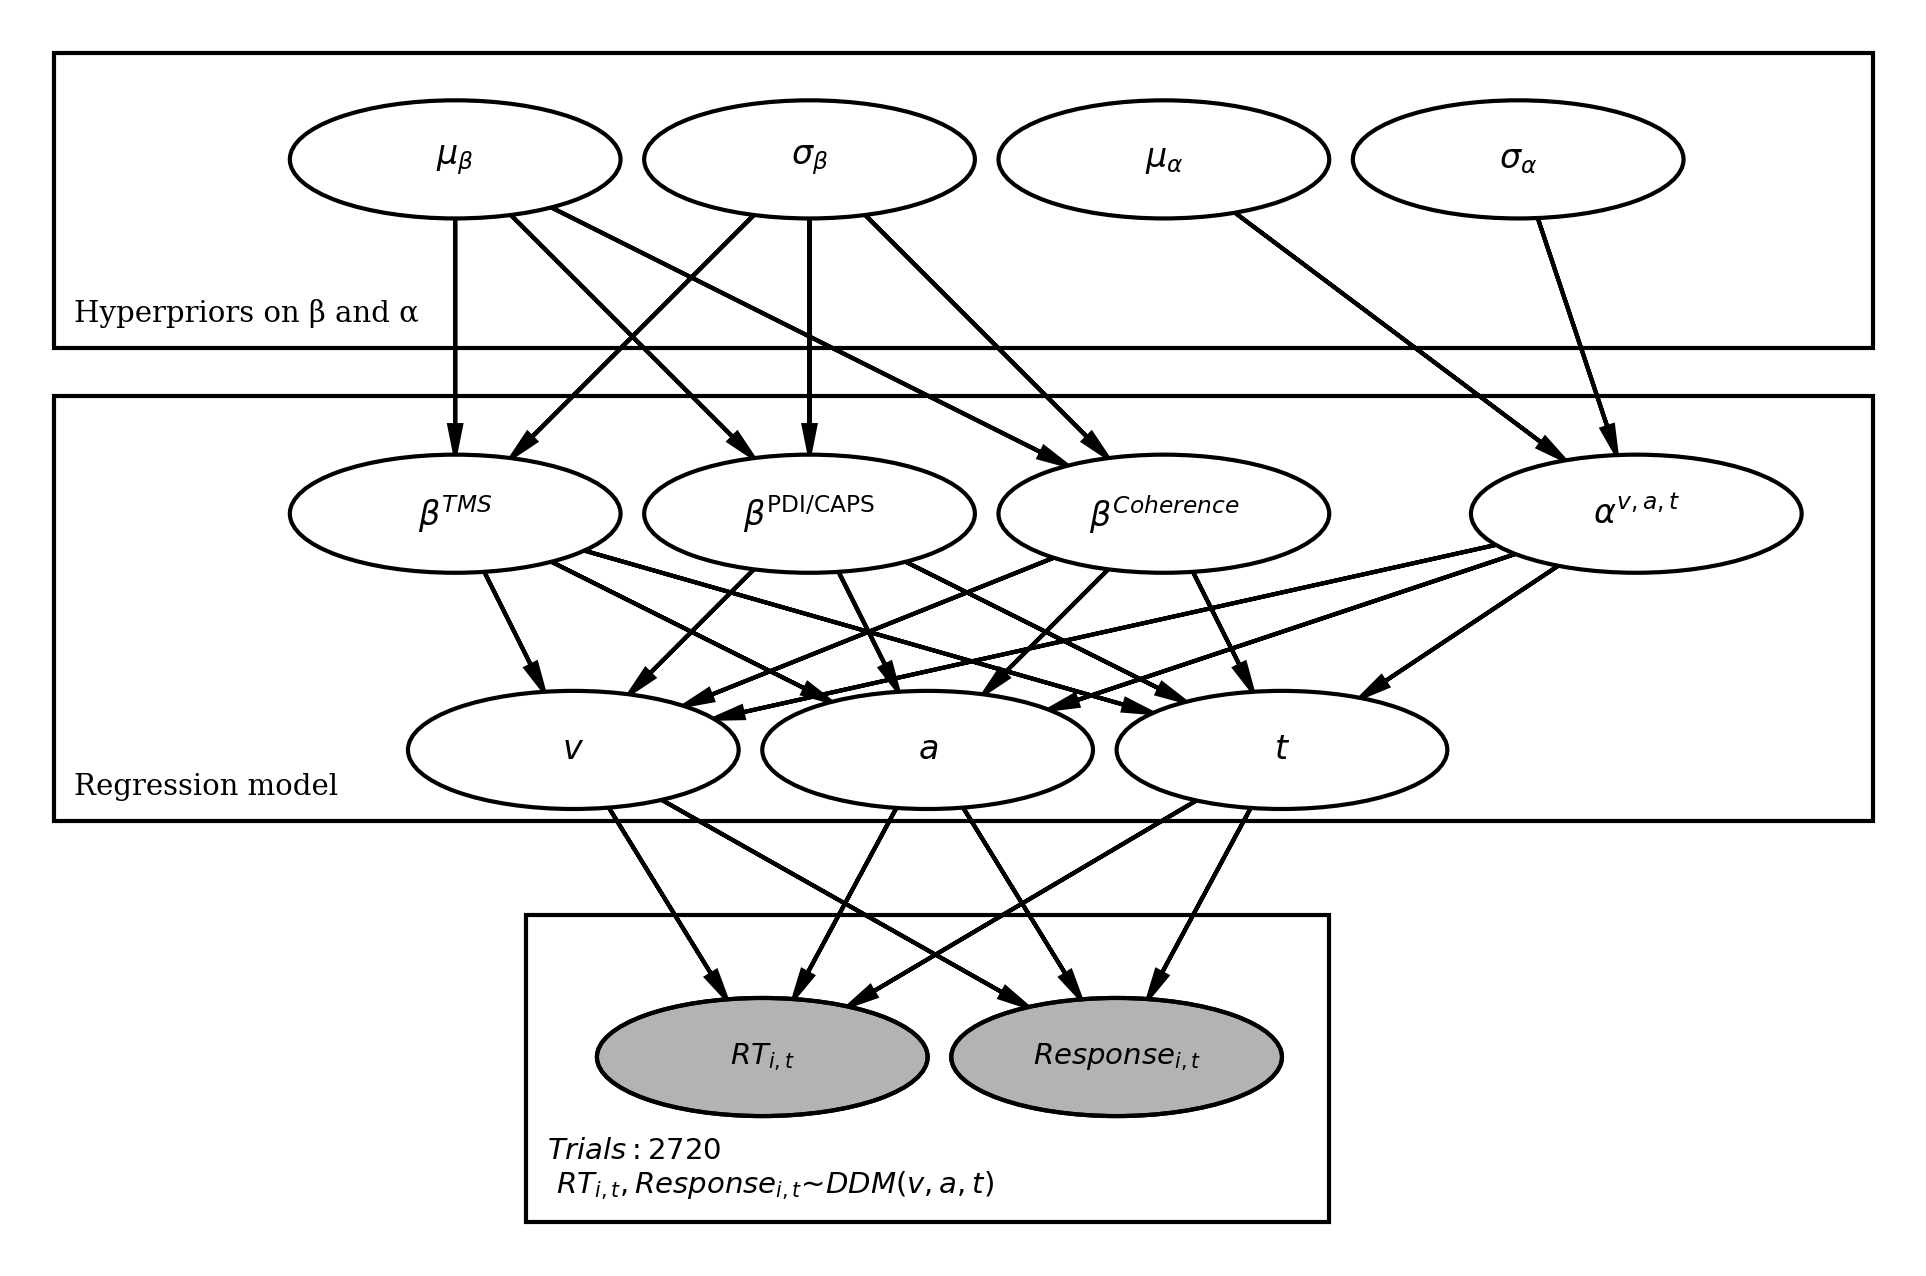

In [153]:
import daft
import matplotlib.pyplot as plt
import matplotlib

# Use LaTeX if available, otherwise fall back safely
matplotlib.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
})

# ----------------------------
# Create PGM
# ----------------------------
pgm = daft.PGM(aspect=2.8, dpi=300)

# ---------------------------------------------------------
# 1. Hyperpriors for Regression Coefficients β
# ---------------------------------------------------------
pgm.add_node("mu_beta",    r"$\mu_{\beta}$",     0.5, 5, fontsize=8)
pgm.add_node("sigma_beta", r"$\sigma_{\beta}$",  2.0, 5, fontsize=8)

# ---------------------------------------------------------
# 2. Hyperpriors for Intercept Coefficients α
# ---------------------------------------------------------
pgm.add_node("mu_alpha",    r"$\mu_{\alpha}$",    3.5, 5, fontsize=8)
pgm.add_node("sigma_alpha", r"$\sigma_{\alpha}$", 5.0, 5, fontsize=8)

# ---------------------------------------------------------
# 3. Predictors
# ---------------------------------------------------------
pgm.add_node("x_tms", r"$\beta^{TMS}$", 0.5, 3.5, observed=False, fontsize=8)

# *** changed here ***
pgm.add_node("x_pdi_caps", r"$\beta^{\text{PDI/CAPS}}$", 2.0, 3.5, observed=False, fontsize=8)

pgm.add_node("x_coh", r"$\beta^{Coherence}$", 3.5, 3.5, observed=False, fontsize=8)
pgm.add_node("Intercept", r"$\alpha^{v,a,t}$", 5.5, 3.5, observed=False, fontsize=8)

# ---------------------------------------------------------
# 4. Deterministic Regression for v, a, t
# ---------------------------------------------------------
pgm.add_node("v", r"$v$", 1.0, 2.5, fontsize=8)
pgm.add_node("a", r"$a$", 2.5, 2.5, fontsize=8)
pgm.add_node("t", r"$t$", 4.0, 2.5, fontsize=8)

# Edges: Regression coefficients → parameters
for x in ["x_tms", "x_pdi_caps", "x_coh", "Intercept"]:
    pgm.add_edge(x, "v")
    pgm.add_edge(x, "a")
    pgm.add_edge(x, "t")

# Edges: Hyperpriors → regression betas
for beta in ["x_tms", "x_pdi_caps", "x_coh"]:
    pgm.add_edge("mu_beta", beta)
    pgm.add_edge("sigma_beta", beta)

# Edges: Hyperpriors → intercept alpha
pgm.add_edge("mu_alpha", "Intercept")
pgm.add_edge("sigma_alpha", "Intercept")

# ---------------------------------------------------------
# 5. RT/Choice Likelihood
# ---------------------------------------------------------
pgm.add_node("rt",   r"$RT_{i,t}$",  1.8, 1.2, observed=True, fontsize=7)
pgm.add_node("resp", r"$Response_{i,t}$",3.3, 1.2, observed=True, fontsize=7)

for param in ["v", "a", "t"]:
    pgm.add_edge(param, "rt")
    pgm.add_edge(param, "resp")

# ---------------------------------------------------------
# Plates
# ---------------------------------------------------------
pgm.add_plate(daft.Plate(
    [-1.2, 4.2, 7.7, 1.25],
    label="Hyperpriors on β and α",
    fontsize=7
))

pgm.add_plate(daft.Plate(
    [-1.2, 2.2, 7.7, 1.8],
    label="Regression model",
    fontsize=7
))

pgm.add_plate(daft.Plate(
    [0.8, 0.5, 3.4, 1.3],
    label=r"$Trials: 2720$" "\n" r"$\ RT_{i,t},Response_{i,t}∼DDM(v,a,t)$",
    fontsize=7
))

# Render figure
fig = pgm.render()

# Fix left cutoff
plt.subplots_adjust(left=0.18, right=0.97, top=0.96, bottom=0.05)

# Save
plt.savefig("hddm_regression_model.png", dpi=300)
plt.show()
